## Feature Engineering - Exploratory Data Analysis (EDA)

## 1. General Imports 

In [1]:
# --- Imports --- #
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import os
import sys


## 2. Configure current notebook directory and project root path 

In [2]:
# --- Configuration to import files from src/ --- #
current_notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_notebook_dir, '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

print(current_notebook_dir)
print(project_root)

C:\Users\Leand\Desktop\2_Projects\1_BTCPriceAnalysis\notebooks
C:\Users\Leand\Desktop\2_Projects\1_BTCPriceAnalysis


## 3. Add the import from 'src/' saved models

In [3]:
# --- Import the 'src/' functions  --- #
from src.data_processing import (
    load_bitcoin_data,
    calculate_returns,
    calculate_moving_averages,
    calculate_volatility,
    calculate_rsi,
    calculate_macd,
    calculate_bollinger_bands, 
    create_lagged_features, 
    create_event_features, 
    run_adfuller_test
)

from src.visualization_utils import (
    plot_price_trend,
    plot_volume_trend,
    plot_correlation_heatmap,
    plot_returns_histogram,
    plot_distribution
)

## 3. Load Data

In [4]:
# -- Load data -- #
print('Loading Bitcoin Data')
try:
    df_bitcoin = load_bitcoin_data()
    print("Data loaded sucesfully. Here's the 5 first rows:")
    print(df_bitcoin.head())
    print("\nDataFrame information:")
    df_bitcoin.info()
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure you have executed '01_data_extraction.ipynb' first.")
    exit() # Exit the code to handle the error accordingly. 

Loading Bitcoin Data
Data loaded sucesfully. Here's the 5 first rows:
                                 Open        High         Low       Close  \
Date                                                                        
2014-09-17 00:00:00+00:00  465.864014  468.174011  452.421997  457.334015   
2014-09-18 00:00:00+00:00  456.859985  456.859985  413.104004  424.440002   
2014-09-19 00:00:00+00:00  424.102997  427.834991  384.532013  394.795990   
2014-09-20 00:00:00+00:00  394.673004  423.295990  389.882996  408.903992   
2014-09-21 00:00:00+00:00  408.084991  412.425995  393.181000  398.821014   

                             Volume  
Date                                 
2014-09-17 00:00:00+00:00  21056800  
2014-09-18 00:00:00+00:00  34483200  
2014-09-19 00:00:00+00:00  37919700  
2014-09-20 00:00:00+00:00  36863600  
2014-09-21 00:00:00+00:00  26580100  

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3948 entries, 2014-09-17 00:00:00+00:00 to 2025

## 5. Create event features (Add after data loading)

In [5]:
df_bitcoin.index = df_bitcoin.index.tz_localize(None)
df_bitcoin = create_event_features(df_bitcoin)
df_bitcoin.head()

,Open,High,Low,Close,Volume,Halving_Event
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,1
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,0
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,0
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,0
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,0


## 4. Feature Engineering - Create Insightful Columns 


In [6]:
print("\nFeature Engineering process started...")

df_bitcoin = calculate_returns(df_bitcoin)
df_bitcoin = calculate_moving_averages(df_bitcoin, windows=[20, 50, 200])
df_bitcoin = calculate_volatility(df_bitcoin)
df_bitcoin = calculate_rsi(df_bitcoin)
df_bitcoin = calculate_macd(df_bitcoin)
df_bitcoin = calculate_bollinger_bands(df_bitcoin)
df_bitcoin = create_lagged_features(df_bitcoin, columns_to_lag=['Close', 'Volume', 'High', 'Low'],
                                        lags=[1,7,30])
print("\DataFrame with new columns (Last 5 rows, showing initial NaN):") 
print(df_bitcoin.tail())
print("\nDataFrame information with new coulmns:")
df_bitcoin.info()


Feature Engineering process started...
\DataFrame with new columns (Last 5 rows, showing initial NaN):
                     Open           High            Low          Close  \
Date                                                                     
2025-07-04  109635.656250  109751.984375  107296.382812  108034.335938   
2025-07-05  108015.835938  108381.343750  107842.273438  108231.179688   
2025-07-06  108231.187500  109731.625000  107847.015625  109232.070312   
2025-07-07  109235.328125  109710.250000  107527.054688  108299.851562   
2025-07-08  108280.382812  109169.828125  107586.625000  108909.085938   

                 Volume  Halving_Event  Simple_Returns  Log_Returns  \
Date                                                                  
2025-07-04  42616442656              0       -0.014717    -0.014826   
2025-07-05  30615537520              0        0.001822     0.001820   
2025-07-06  36746020463              0        0.009248     0.009205   
2025-07-07  4541569659

## 5. Exploratory Data Analysis (EDA) - Visualizations

### 5.1 Price Trend Visualization



Generating price trend visualizations...


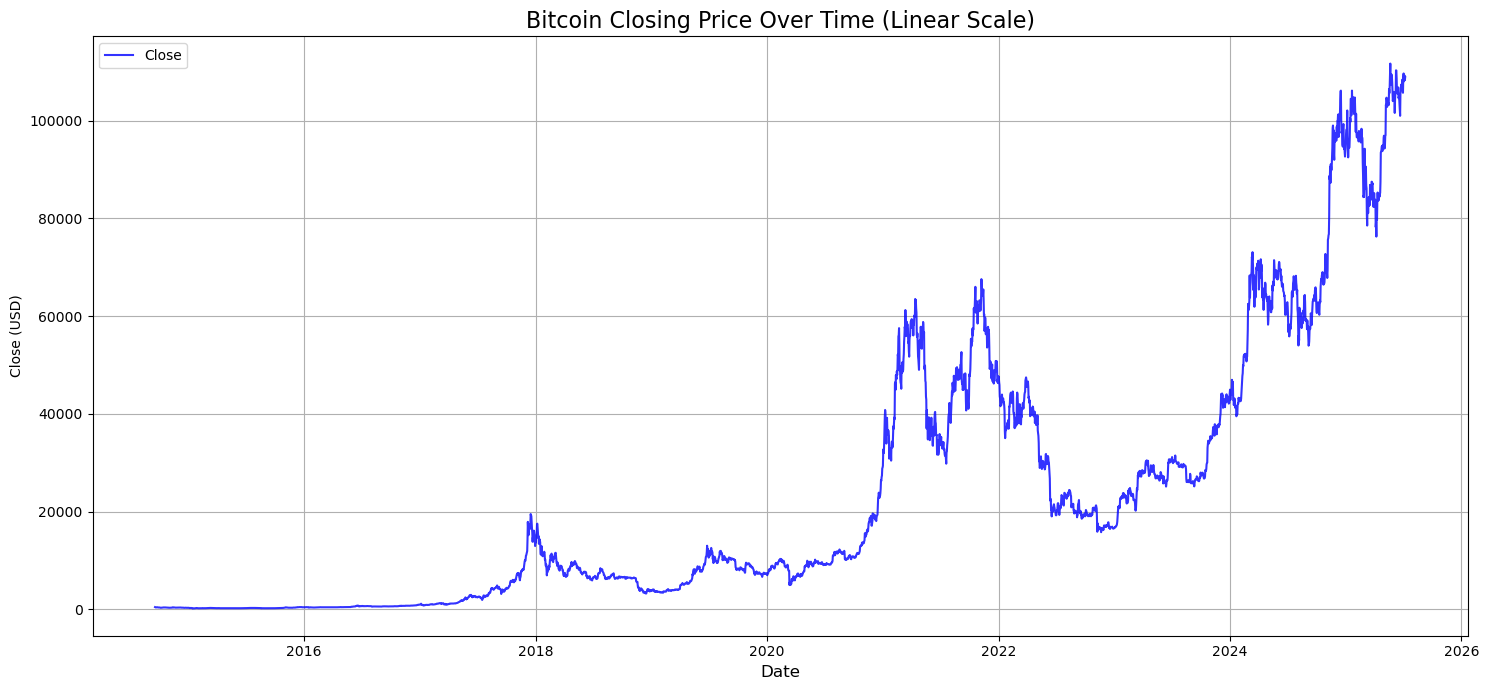

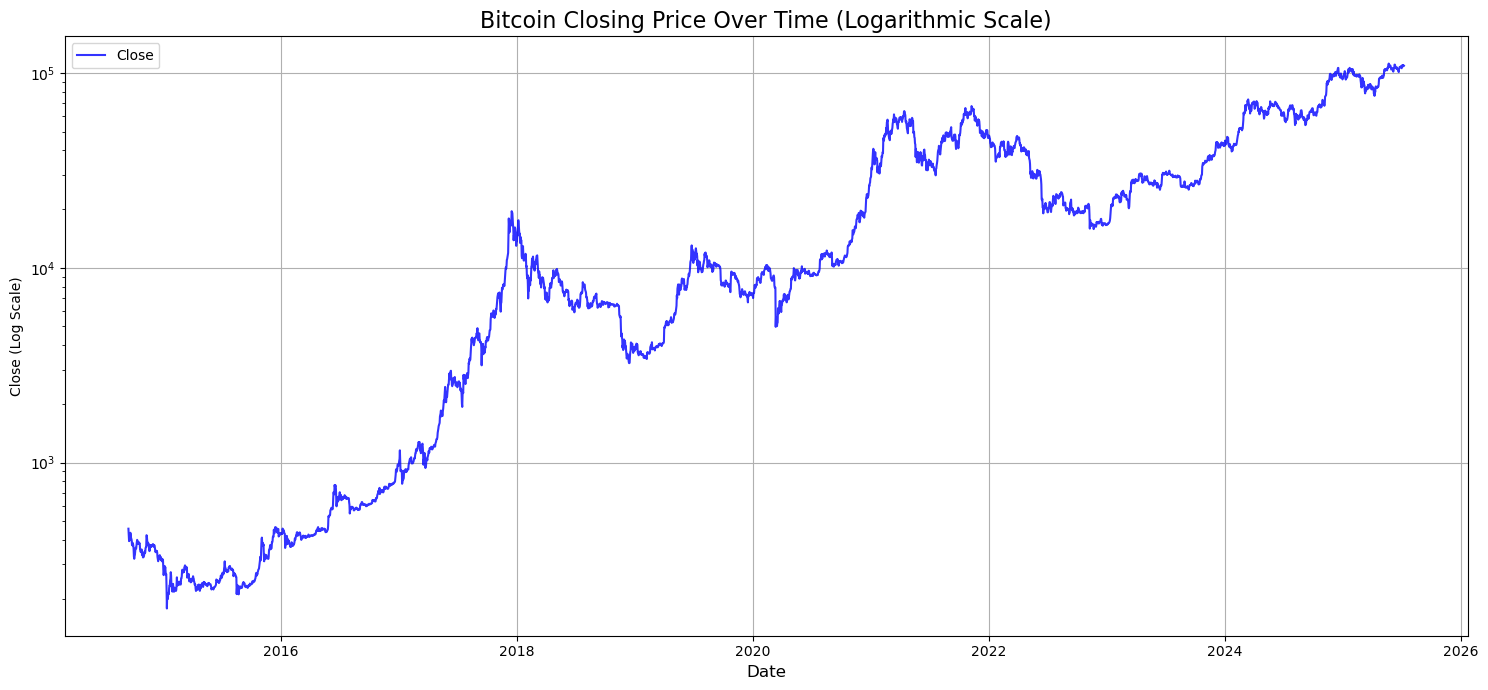

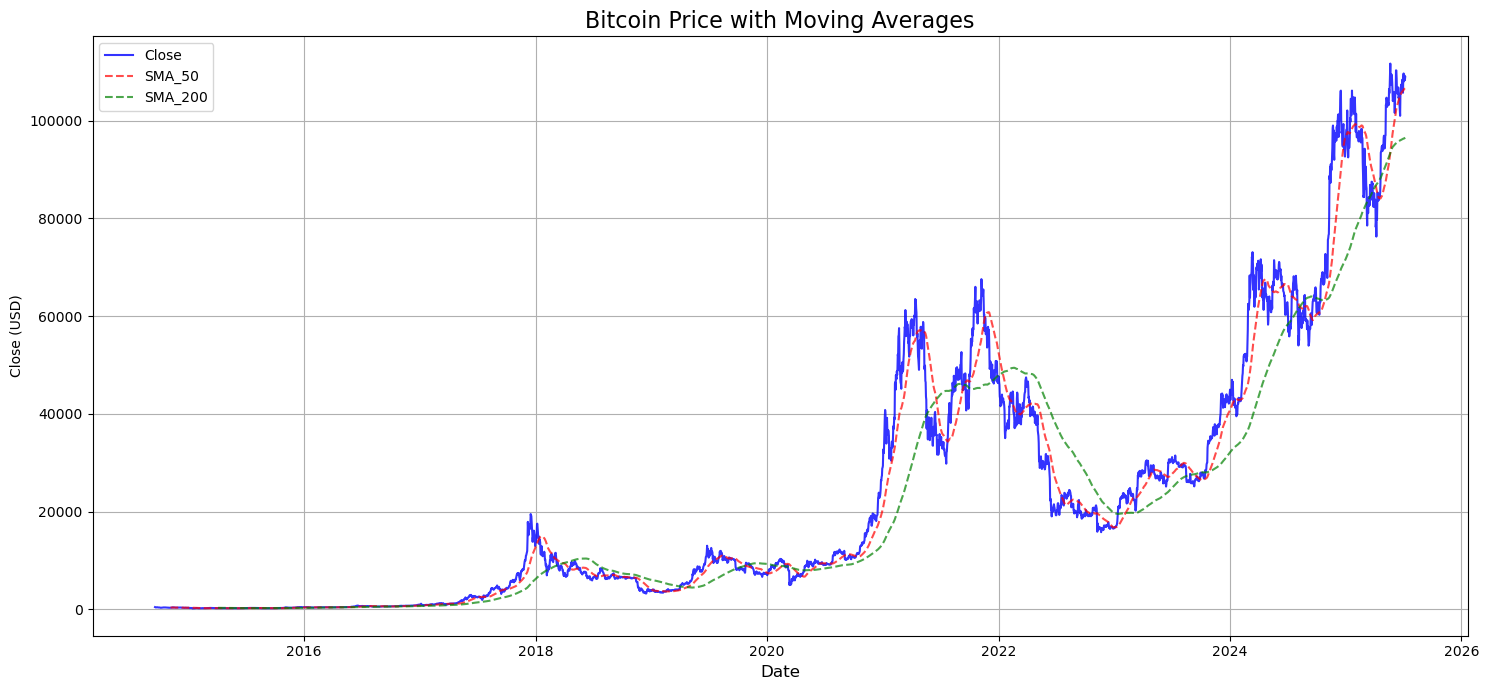

In [7]:
print("\nGenerating price trend visualizations...")
# -- Price Trend Linear Scale -- #
plot_price_trend(df_bitcoin, price_col='Close', title="Bitcoin Closing Price Over Time (Linear Scale)", 
                 scale='linear')
# -- Price Trend Logarithmic Scale -- #
plot_price_trend(df_bitcoin, price_col="Close", title="Bitcoin Closing Price Over Time (Logarithmic Scale)",
                 scale='log')
# -- Price Trend Moving Averages -- #
plot_price_trend(df_bitcoin, price_col="Close", title="Bitcoin Price with Moving Averages", 
                 additional_lines=[{"col": "SMA_50", "label": "SMA_50", "color": "red", "linestyle": "--"},
                                   {"col": "SMA_200", "label": "SMA_200", "color": "green", "linestyle": "--"}
                                  ])


### 5.2 Volume Over Time Visualization

Generating Volume over time visualization


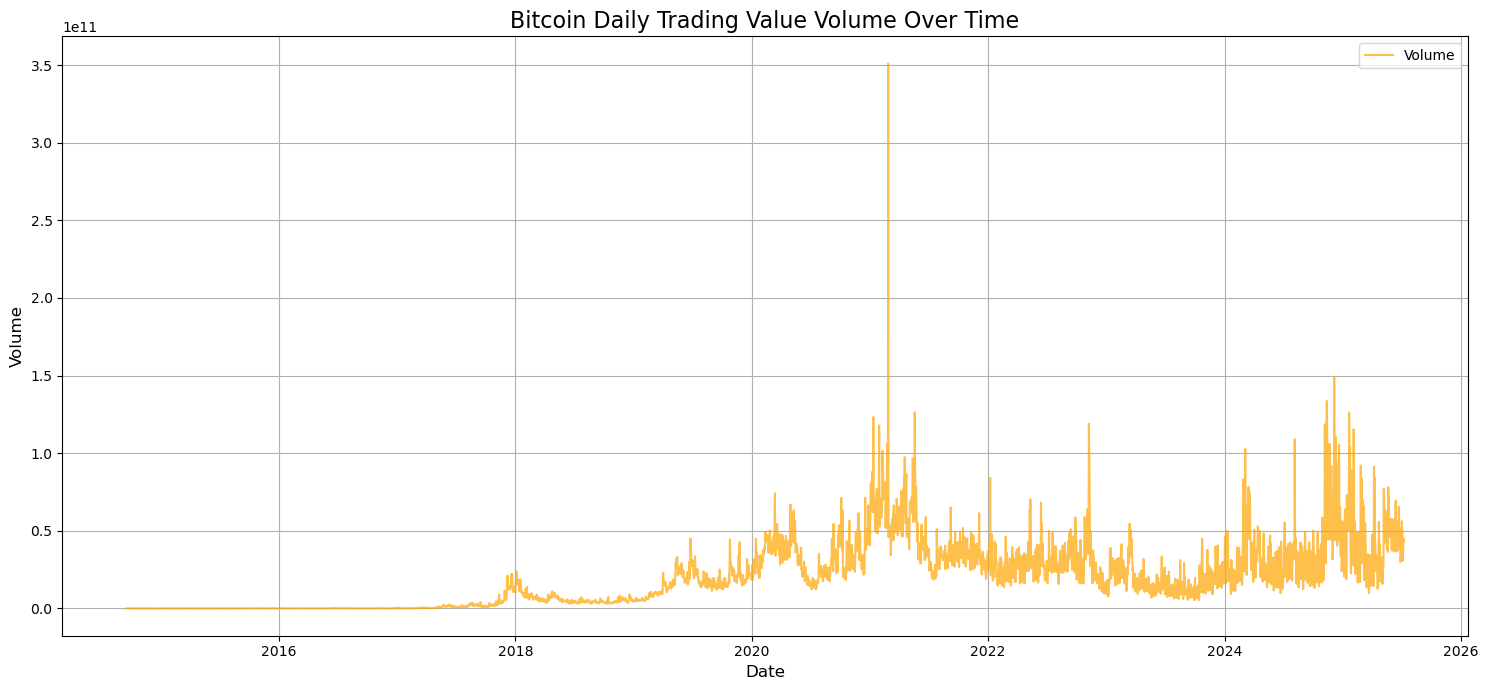

In [8]:
print("Generating Volume over time visualization")
# -- Volume over time visualization-- #
plot_volume_trend(df_bitcoin, title="Bitcoin Daily Trading Value Volume Over Time")

### 5.3 Correlation Matrix

 Generating Correlation Matrix


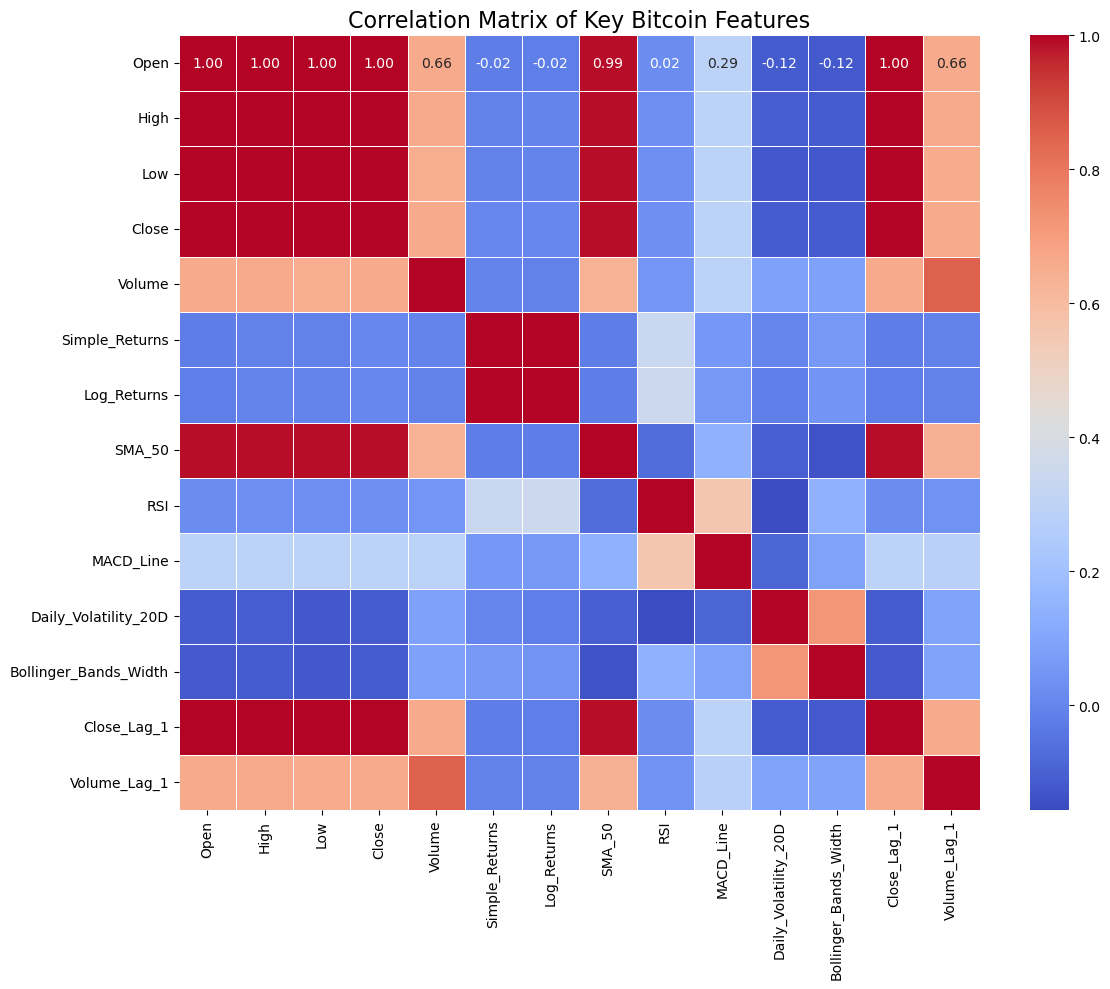

In [9]:
print(" Generating Correlation Matrix")
# -- Correlation Matrix Visualization-- #
columns_for_corr = [
    "Open", "High", "Low", "Close", "Volume", 
    "Simple_Returns", "Log_Returns", "SMA_50", "RSI", "MACD_Line", 
    "Daily_Volatility_20D", "Bollinger_Bands_Width", "Close_Lag_1", "Volume_Lag_1"
]
plot_correlation_heatmap(df_bitcoin, columns=columns_for_corr, title='Correlation Matrix of Key Bitcoin Features')

### 5.4 Seasonal Decomposition

Generating (Weekly) Decomposition


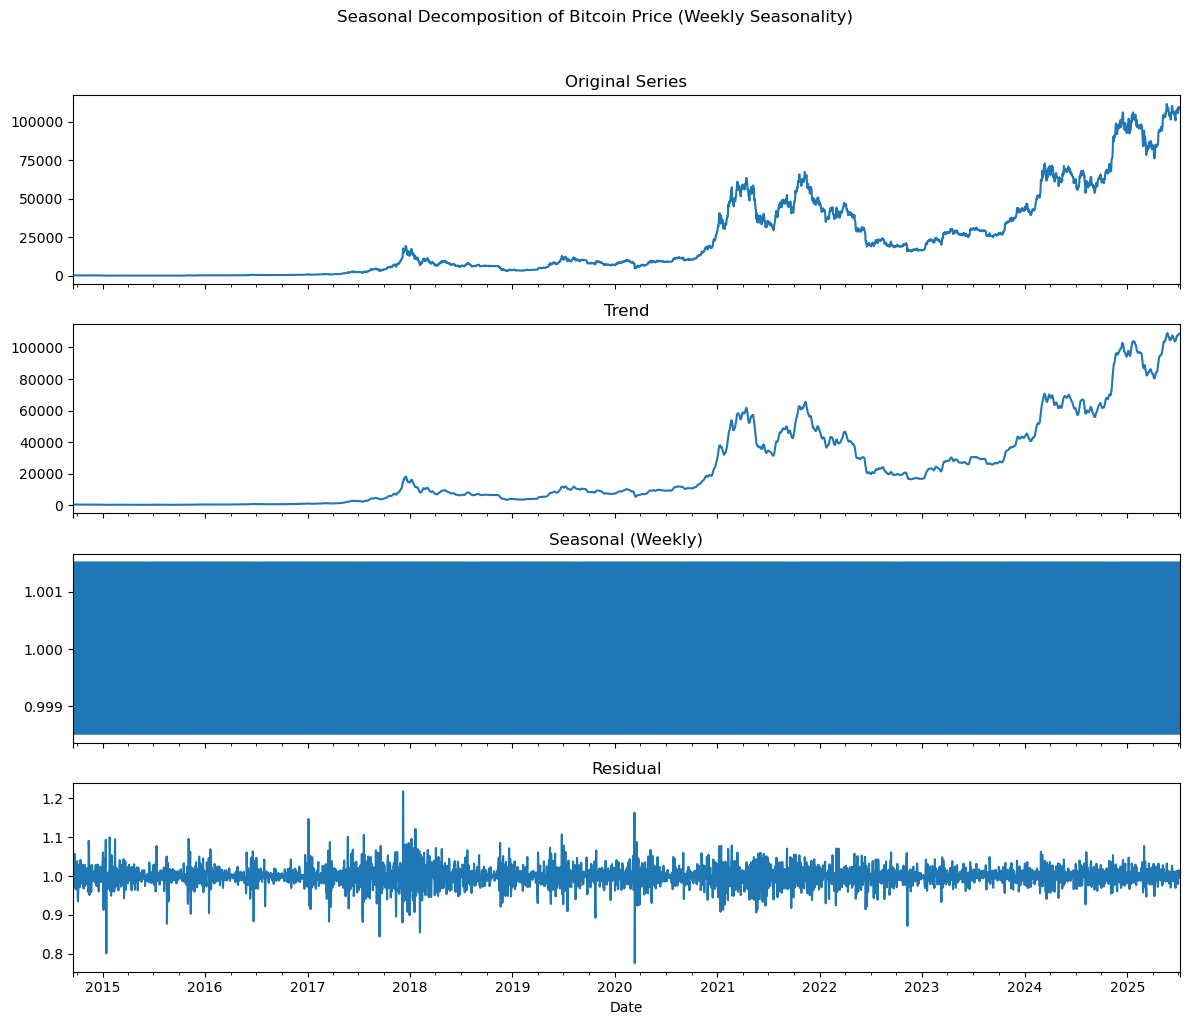

In [10]:
print("Generating (Weekly) Decomposition")
try:
    df_decomp = df_bitcoin["Close"].dropna()
    decomposition_weekly = seasonal_decompose(df_decomp, model='multiplicative', period=7)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(12, 10), sharex=True)
    decomposition_weekly.observed.plot(ax=ax1, title="Original Series")
    decomposition_weekly.trend.plot(ax=ax2, title="Trend")
    decomposition_weekly.seasonal.plot(ax=ax3, title="Seasonal (Weekly)")
    decomposition_weekly.resid.plot(ax=ax4, title="Residual")
    plt.suptitle("Seasonal Decomposition of Bitcoin Price (Weekly Seasonality)", y=1.02)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Unsucessfull (Weekly) Decomposition: {e}. Make sure that there's enough continuous data")
    print("Consider adjusting the 'Period' if your data are not extensive enough or if it has a lot of NaN")

### 5.6 Stationary Analysis (Augmented Dickey-Fuller - ADF)

In [11]:
print("\n Generating stationary test (ADF)")

# -- Run ADF Test for Logarithmic Returns -- #
run_adfuller_test(df_bitcoin['Log_Returns'], name='Logarithmic Return')

# Test the closing price first difference
df_bitcoin['Close_Diff1'] = df_bitcoin['Close'].diff().dropna()
run_adfuller_test(df_bitcoin['Close_Diff1'], name='Closing Price First Diference')


 Generating stationary test (ADF)

--- ADF Test Results for: Logarithmic Return ---
ADF Statistics: -19.077635232759686
p-value: 0.0
#Lags Used: 9
Number of Observations Used: 3937
Conclusion: Null (H0)  Hypothesis REJECTED. The series IS STATIONARY (or it doesn't have a unitary root.

ADF test completed.

--- ADF Test Results for: Closing Price First Diference ---
ADF Statistics: -9.241448301795879
p-value: 1.5785372046119188e-15
#Lags Used: 30
Number of Observations Used: 3916
Conclusion: Null (H0)  Hypothesis REJECTED. The series IS STATIONARY (or it doesn't have a unitary root.

ADF test completed.


### Important - SAVE THE FILE

In [18]:
# Assigned the name to the file
file_name = 'Enriched_Bitcoin_Price_Analysis.csv'

# Root path of the file
output_dir = os.path.join(project_root, 'data', 'enriched_data')
output_path = os.path.abspath(os.path.join(output_dir, file_name))

# Create folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the file
df_bitcoin.to_csv(output_path)
print(f"File saved in: {output_path}")

File saved in: C:\Users\Leand\Desktop\2_Projects\1_BTCPriceAnalysis\data\enriched_data\Enriched_Bitcoin_Price_Analysis.csv


## 6. Key Findings and Insights

### 6.1 Understanding Your ADF Test Results
Your ADF test results confirm that both your Logarithmic Returns and the First Difference of the Closing Price are stationary. This is a crucial finding and a very positive step forward for your forecasting project.

Let's break down what these results mean:

- ADF Statistic (e.g., -19.077 for Log Returns): A more negative value indicates stronger evidence against the null hypothesis (i.e., stronger evidence for stationarity). Your values are very negative, which is great.

- p-value (e.g., 0.0 for Log Returns, 1.57e-15 for First Difference): The p-value is the probability of observing your data if the null hypothesis were true.

- Since both p-values are less than or equal to 0.05 (the common significance level), you reject the null hypothesis (H 
0).

##### Conclusion: This means you have strong statistical evidence to conclude that both series (Log Returns and Closing Price First Difference) are stationary.

#### 6.2 What This Means for Your Forecasting Models:

This stationarity confirmation is vital, especially if you plan to use ARIMA-based models (AutoRegressive Integrated Moving Average) or other statistical time series models.

For Logarithmic Returns: Since your Log_Returns are stationary, you can directly use them as the target variable for forecasting models that require stationarity. Many financial models prefer log returns because their properties (like additivity) are better suited for statistical analysis.

For Closing Price First Difference: The fact that the first difference of the Close price is also stationary confirms that differencing the original price series once (an "I" of 1 in ARIMA, or Integrated component) is sufficient to achieve stationarity for models that operate on the differenced series.

#### 7. Next Steps: Moving to Forecasting

You've successfully set up your project, performed a comprehensive EDA, engineered insightful features, and confirmed the stationarity of key series. You're now perfectly poised for the next phase.

The next logical step in your project, as planned, is to move into: 

##### Time series Modeling (notebooks/03_time_series_forecasting.ipynb)